## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [201]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func

### Path to results directory 
data_dir = '/project/paris/inverse_modelling/'

### Set ppt_mode to True for bigger fonts
ppt_mode = False

### Group the models of interest in meaningful experiment names 
experiments = {'std_run'       :['intem_name_edgar','elris_name_edgar','rhime_name_edgar'], # Standard run 
               'obs_selection' :['intem_name_edgar','intem_name_edgar_allobs',              # Effect of obs selection
                                 'elris_name_edgar','elris_name_edgar_allobs',
                                 'rhime_name_edgar','rhime_name_edgar_allobs'],
               'elris_edgar'    :['elris_name_edgar','elris_name_edgar_allobs',              # Effect of transport model and obs selection (ELRIS only)
                                  'elris_flex_edgar','elris_flex_edgar_allobs'],
               'wetcharts'      :['intem_name_wetcharts_31sites','elris_name_wetcharts_31sites',
                                  'rhime_name_wetcharts_31sites']
              }

###################################

s_data,m_data,m_colors,annotate_coords = func.initialize_settings(ppt_mode)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [211]:
###################################
### edit variables in this block
species = 'hfc134a' #options for individual species, or 'all_hfc' or 'all_pfc'
models = experiments['std_run'] #if using 'all_hfc' or 'all_pfc' use basic model names (e.g. ['intem','elris','rhime']) and standard filenames will be used for each species
regions = ['GERMANY','UK','BENELUX','NW_EU2']
scale_co2eq = False
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2024-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year

###################################

ds_all_flux_scaled = {}

if 'all' in species:
    ds_all_flux_scaled = func.read_flux_total_fgases(data_dir,species,models,s_data,m_data,
                                                     regions,start_date,end_date,
                                                     period_override=period_override)
else:
    ds_all_flux = func.read_flux(data_dir,species,models,s_data,m_data,period_override=period_override)

    for m in models:
        ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,s_data,scale_units=True,
                                    scale_co2eq=scale_co2eq,species=species)[m]

model_colors = func.set_model_colors_2(models,m_colors)


Attempting to read data from intem_name_edgar
Reading data from: /project/paris/inverse_modelling/InTEM/hfc134a/InTEM_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_optimized_hfc134a_yearly.nc
Done!

Attempting to read data from elris_name_edgar
Reading data from: /project/paris/inverse_modelling/ELRIS/hfc134a/ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized_HFC_134a_yearly.nc
Done!

Attempting to read data from rhime_name_edgar
Reading data from: /project/paris/inverse_modelling/RHIME/hfc134a/RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_hfc134a_yearly.nc
Done!

Masking data from intem_name_edgar
Scaling intem_name_edgar country fluxes by 1000000.0

Masking data from elris_name_edgar
Scaling elris_name_edgar country fluxes by 1000000.0
Scaling covariance in elris_name_edgar by 1000000000000.0

Masking data from rhime_name_edgar
Scaling rhime_name_edgar country fluxes by 1000000.0


#### Timeseries of country fluxes:

No inventory data available for BENELUX. Considering sum of individual countries: BEL-LUX-NLD
BENELUX emissions are not present in elris_name_edgar. Considering covariance matrix and sum of individual countries: BEL-LUX-NLD.
No inventory data available for NW_EU2. Considering sum of individual countries: BEL-DEU-FRA-GBR-IRL-LUX-NLD
NW_EU2 emissions are not present in elris_name_edgar. Considering covariance matrix and sum of individual countries: BEL-DEU-FRA-GBR-IRL-LUX-NLD.
NOTE: If all the data is not within axis limits, adjust the set_ylim parameter


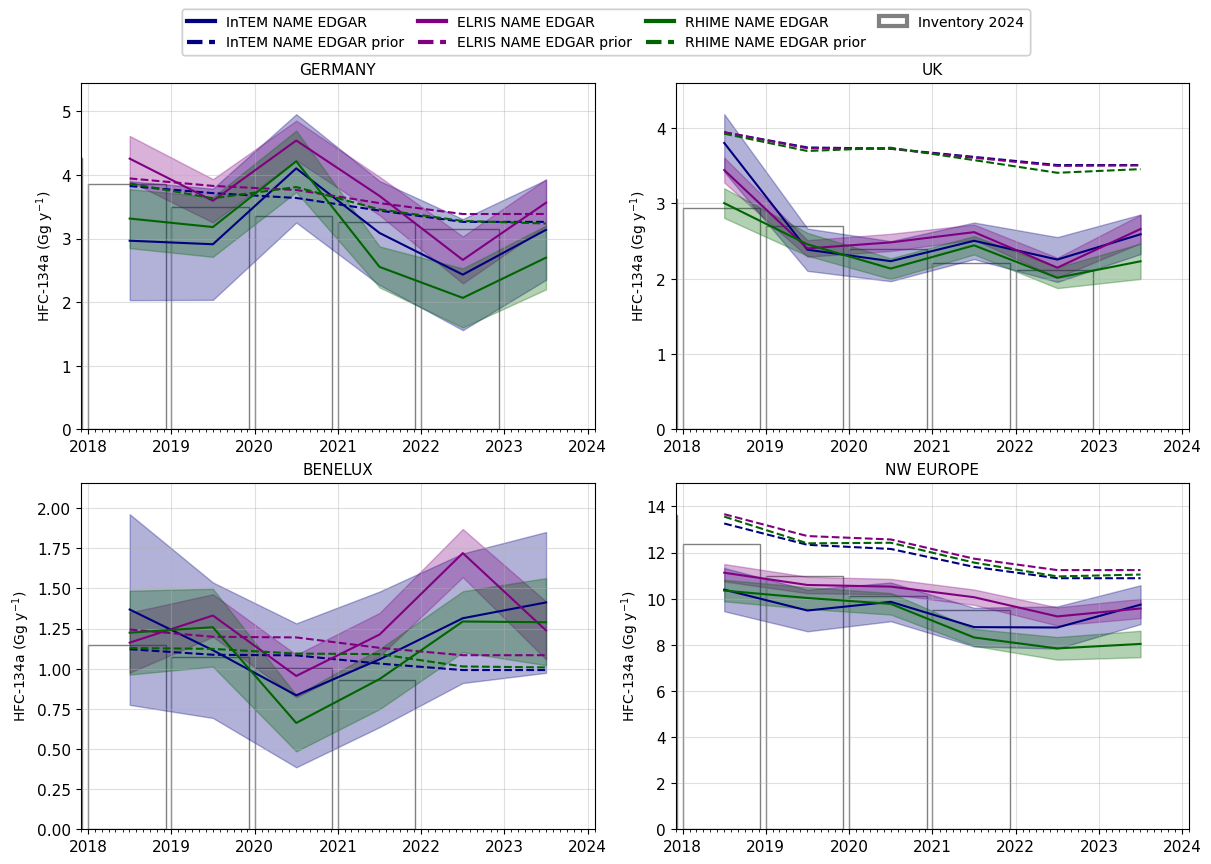

In [212]:
###################################
### edit variables in this block
plot_inventory = True
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior = True #if True: plots prior as dashed lines
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles. Set to None for no title.
plot_separate = True #If True, includes all model results as separate lines (or insert a list of boolean of the same length as models to specify which models to plot)
plot_combined = False #If True, combined results, averaged from all models (or insert a list of boolean of the same length as models to specify which models to combine)
resample = None #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
plot_resample_and_original = False #If True, plots both the resampled and original data
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,regions,
                             s_data,m_data,model_colors,start_date,end_date,ppt_mode,scale_co2eq,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,add_prior,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             plot_separate=plot_separate,plot_combined=plot_combined,
                             resample=resample,
                             plot_resample_and_original=plot_resample_and_original,
                             period_override=period_override)

Save plot here:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/flux_country.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
###################################
### edit variables in this block
species = 'hfc134a' 
site = 'MHD'
models = experiments['std_run']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive
end_date = '2019-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs                - total observed mole fraction
# uYobs_repeatability - observed repeatability mole fraction uncertainty
# uYobs_variability   - observed variability mole fraction uncertainty
# uYmod               - model mole fraction uncertainty
# uYtotal             - total mole fraction uncertainty
# Yapriori            - prior total mole fraction
# Yapost              - posterior total mole fraction
# YaprioriBC          - prior baseline
# YapostBC            - posterior baseline
# Ybias               - posterior bias added to site
# YaprioriOuter       - prior mole fractions only from outer regions
# YapostOuter         - posterior mole fractions only from outer regions
###################################


ds_all_mf = func.read_mf(data_dir,species,models,s_data,m_data,period_override=period_override)

ds_all_mf_sliced = func.slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

model_colors = func.set_model_colors_2(models,m_colors)

#### Plot timestamps with data at each site:

In [ ]:
fig = func.plot_sites_timeseries(ds_all_mf,'Yapost',start_date,end_date,model_colors,m_data)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/sites.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, separated by model:

In [ ]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,
                                    model_colors,s_data,m_data,annotate_coords,ppt_mode,
                                    include=['Yobs','Yapost'],
                                    diff_include=['Yapost'],
                                    y_lim=None)

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
# - To choose y axis limits set y_lim=[min_value,max_value]
###################################

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_timeseries.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,
                                    model_colors,s_data,m_data,annotate_coords,ppt_mode,
                                    include=['Yapost'],
                                    diff_include=['Yapost'],
                                    y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_allmodels.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,
                        model_colors,s_data,m_data,annotate_coords,ppt_mode,
                        include=['Yapost'],
                        diff_include=['Yapost'],
                        y_lim=None)

Save plot:

In [ ]:
# output_path = '/project/paris/users/AlexDanjou/images/Yapost_diff.png'

# fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),s_data,start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites)

fig = func.plot_stats_mf(pearson,nrmse,species,
                         model_colors,s_data,m_data,
                         start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [213]:
###################################
### edit variables in this block
species = 'hfc134a'
start_date = '2018-01-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2019-01-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
models = experiments['std_run']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
convert_flux_units = True #if true, convert molar flux to mass flux
###################################

ds_all_flux = func.read_flux(data_dir,species,models,s_data,m_data,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,s_data,scale_units=True
                                            ,convert_flux_units=convert_flux_units,species=species)[m]


Attempting to read data from intem_name_edgar
Reading data from: /project/paris/inverse_modelling/InTEM/hfc134a/InTEM_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_optimized_hfc134a_yearly.nc
Done!

Attempting to read data from elris_name_edgar
Reading data from: /project/paris/inverse_modelling/ELRIS/hfc134a/ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized_HFC_134a_yearly.nc
Done!

Attempting to read data from rhime_name_edgar
Reading data from: /project/paris/inverse_modelling/RHIME/hfc134a/RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_hfc134a_yearly.nc
Done!

Masking data from intem_name_edgar
Scaling intem_name_edgar country fluxes by 1000000.0
Converted variables to kg km-2 yr-1:
 ['flux_total_prior', 'flux_total_prior_out', 'flux_total_posterior', 'percentile_flux_total_prior', 'percentile_flux_total_prior_out', 'percentile_flux_total_posterior']

Masking data from elris_name_edgar
Scaling elris_name_edgar country fluxes by 1000000.0
Scaling covariance in elr

##### Prior and posterior fluxes for all models:


Plotting markers for: ['paris', 'london']
Edit lines below line 2656 to change marker colour and size


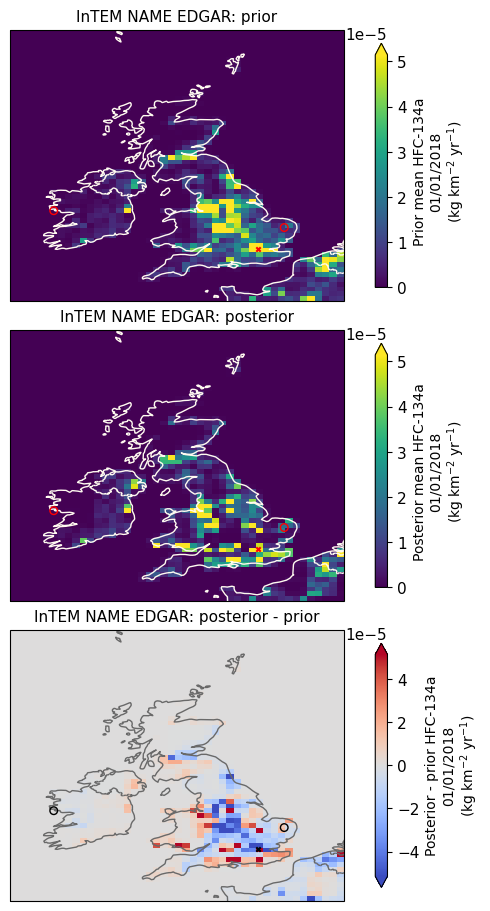

In [209]:
###################################
### edit variables in this block
plot_area = 'UK' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NETHERLANDS, IRELAND, HUNGARY, NORWAY, NWEU, CWEU, EUROPE
cmap = 'viridis'   #Greens
cmap_diff = 'coolwarm'
c_border = 'floralwhite'    #country boundary colour
plot_site_locations = True #If True, adds markers to plots at locations of obs sites 
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
season = None #If specified plot the seasonal mean (only valable for monthly data). Options for 'DJF', 'MAM', 'JJA' and 'SON'
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'default'|'auto'
                        # 'default' = species_info default values and 'auto' = 99th percentile of flux_total_posterior
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,s_data,m_data,
                             cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                             period_override=period_override,plot_site_locations=plot_site_locations,
                             plot_point_markers=plot_point_markers,
                             season=season,set_fluxlim=set_fluxlim)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Directly compare posterior fluxes from two models:

No sites data available in elris_name_edgar attrs, so using site data from intem_name_edgar

Plotting markers for: ['paris', 'london']
Edit lines below line 2887 to change marker colour


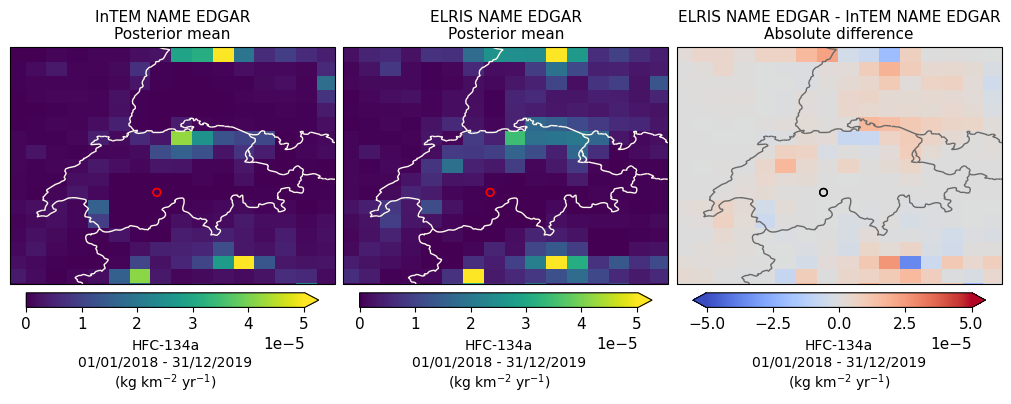

In [161]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,s_data,m_data,ppt_mode,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers,
                                        set_fluxlim=set_fluxlim)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Plot prior, posterior or difference fluxes per time interval:

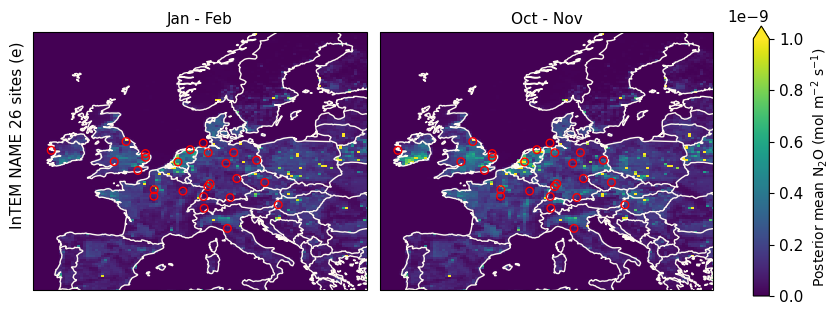

In [190]:
###################################
### edit variables in this block
plot_area = 'CWEU'       #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NETHERLANDS, IRELAND, HUNGARY, NORWAY, NWEU, CWEU, EUROPE
cmap = 'viridis'         #flux colour (e.g. 'viridis', 'coolwarm')
c_border = 'floralwhite' #country boundary colour (e.g. 'floralwhite', 'dimgrey')
chop_by = 'year'  #time unit of the averaging period (options for 'year', 'month' and 'season')
                  #alternatively, a list of starting dates can be provided (format '2018-01-01')
dt = 1  #number of time steps (in chop_by units) to use in the averaging
         #if chop_by='season': set dt to a list of lists with the months to use in the average (e.g. dt=[[1,2],[10,11]], will average over Jan-Feb and Oct-Nov)
var = 'flux_total_posterior'  #variable to be plotted. Options for: 'flux_total_posterior', 'flux_total_prior', 'posterior_prior_diff', 'posterior_mean_diff'
plot_combined = False
plot_site_locations = True    #If True, adds markers to plots at locations of obs sites
plot_point_markers = None #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
set_fluxlim = 'auto' # Set flux colorbar limits: e.g.[0,10]|'default'|'auto'
                        # 'default' = species_info default values and 'auto' = 99th percentile of var
###################################

fig = func.plot_spatial_flux_per_timestamp(ds_all_flux_scaled,species,plot_area,end_date,s_data,m_data,
                                            cmap=cmap,c_border=c_border,var=var,
                                            plot_combined=plot_combined,chop_by=chop_by,dt=dt,period_override=period_override,
                                            plot_site_locations=plot_site_locations,
                                            plot_point_markers=plot_point_markers,
                                            set_fluxlim = set_fluxlim)

Save plot:

In [ ]:
#output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')